:::writing “”" GLOBAL PROTEST ANALYSIS – OVERVIEW MODULE
Project: Global Protest Risk & Escalation Analysis

This script performs exploratory data analysis (EDA) on the global protest dataset

and generates visual insights about protest dynamics across countries, regions,

and time.

The purpose of this module is to provide a high‑level overview of protest activity

before moving to advanced risk modeling and escalation analysis.

Main objectives:

Understand global protest trends over time
Identify the most active protest regions
Analyze the evolution of protest violence
Detect countries with the highest protest activity
Identify cities with the most protest events
Dataset:

Protest_pg_ready.csv

Key Variables Used:

Year
Country name
Region
Location of Protest
Protester Violence
Analytical Outputs:

Global protest trend (time series)
Regional protest distribution
Violence rate evolution
Top protest countries
Most active protest cities
Visualization Tools:

Matplotlib
Seaborn
Output:

A cleaned overview dataset is exported for dashboarding in Power BI:

protests_overview_export.csv

Author: Data Analysis Project

Module: Overview Analysis

“”"

:::

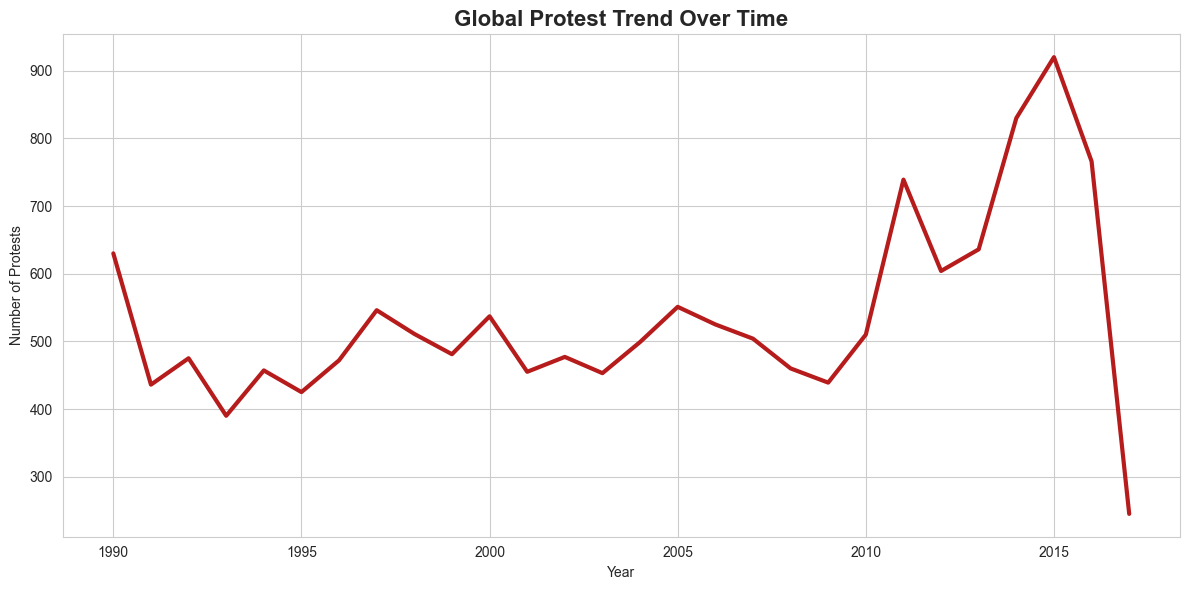

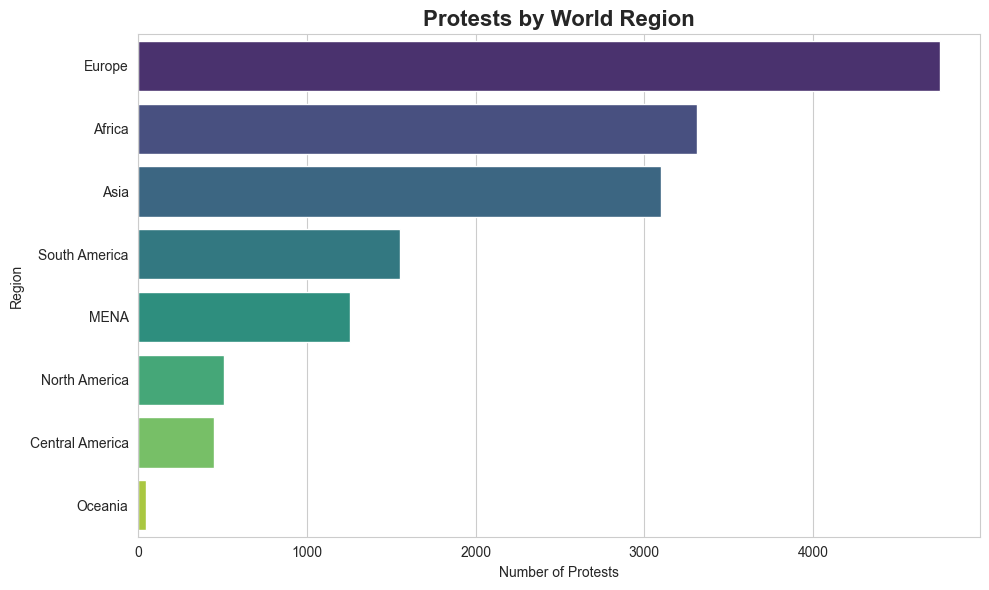

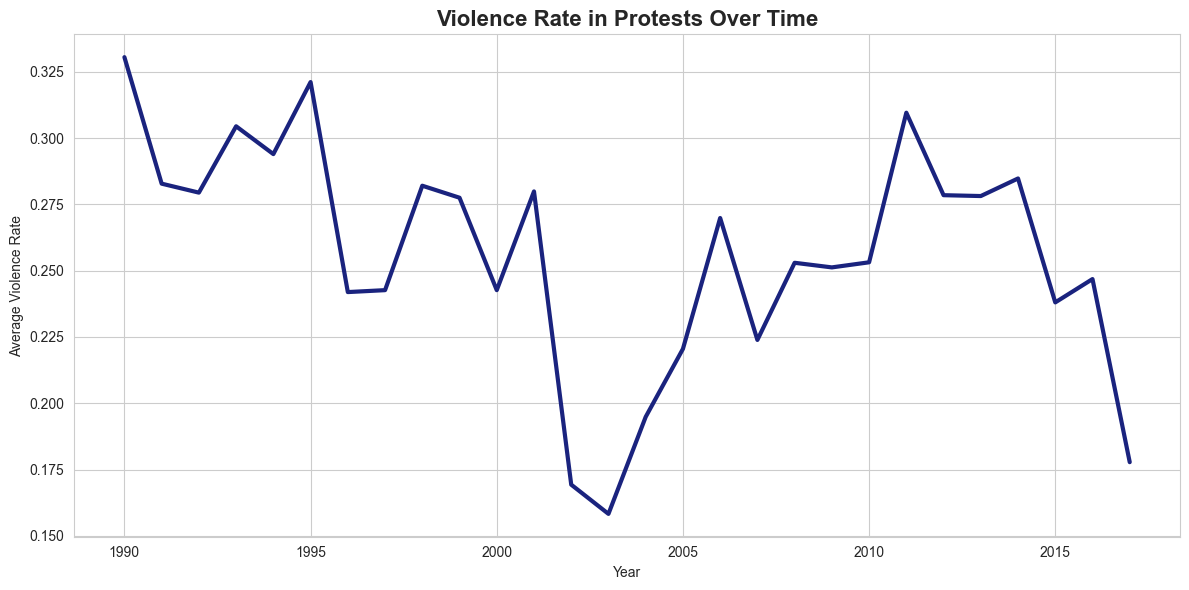

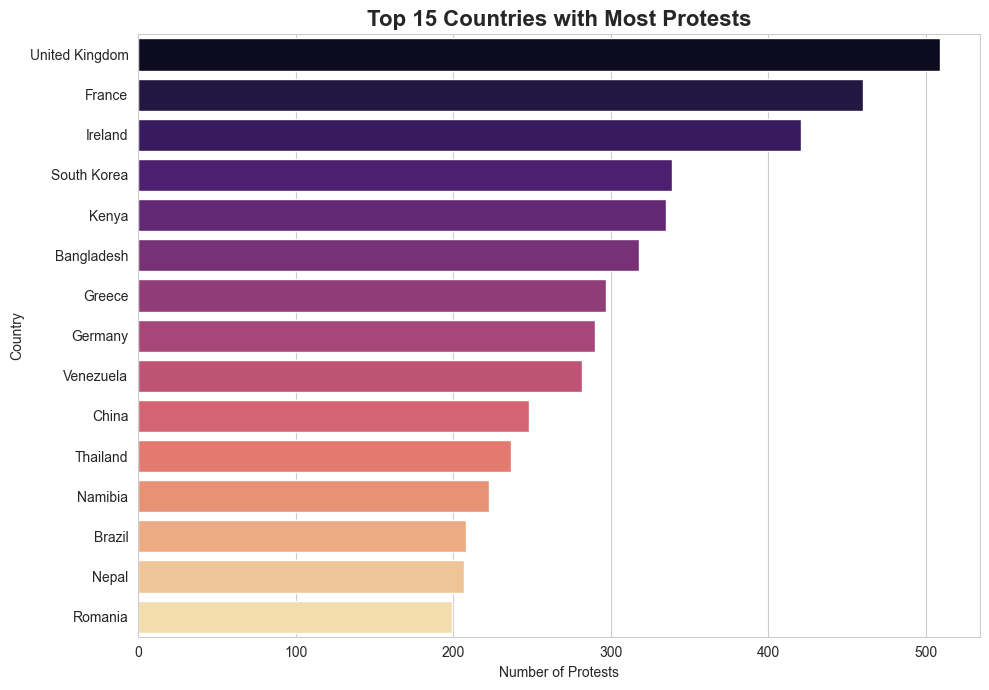

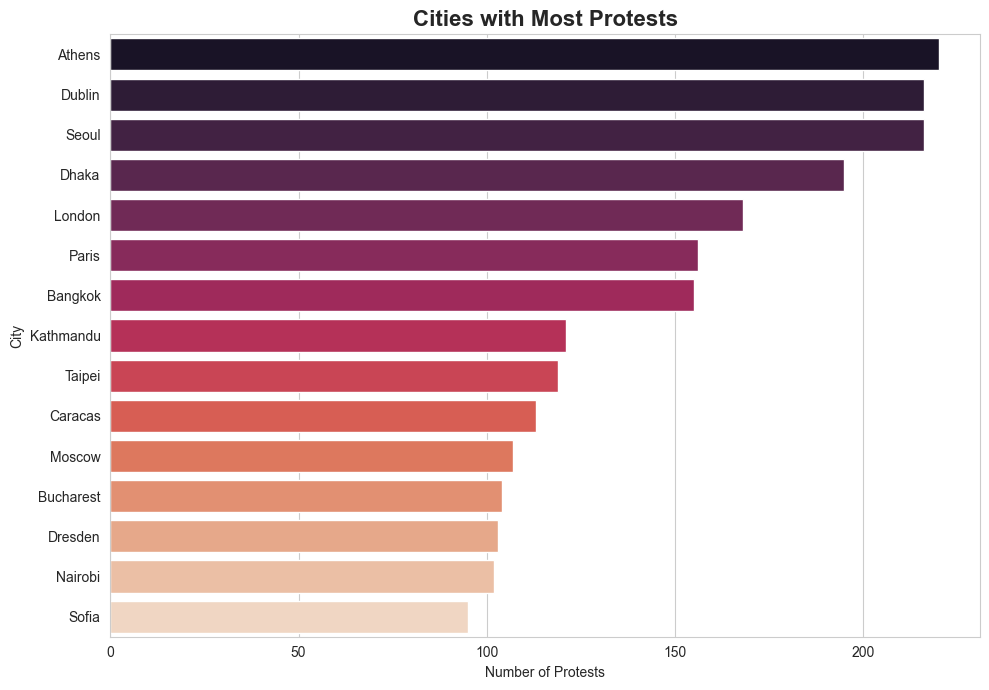

✅ Export completed: protests_overview_export.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# -----------------------------
# Load Data
# -----------------------------

file_path = "Protest_pg_ready.csv"
df = pd.read_csv(file_path, sep=";", low_memory=False)

# -----------------------------
# Basic Cleaning
# -----------------------------

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Protester Violence"] = pd.to_numeric(df["Protester Violence"], errors="coerce")

df = df.dropna(subset=["Year"])

# -----------------------------
# 1️⃣ Global Protest Trend
# -----------------------------

yearly_protests = df.groupby("Year").size().reset_index(name="Protests")

plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_protests,
    x="Year",
    y="Protests",
    color="#b71c1c",
    linewidth=3
)

plt.title("Global Protest Trend Over Time", fontsize=16, weight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Protests")

plt.tight_layout()
plt.show()

# -----------------------------
# 2️⃣ Protests by Region
# -----------------------------

region_counts = df["Region"].value_counts().reset_index()
region_counts.columns = ["Region", "Protests"]

plt.figure(figsize=(10,6))

sns.barplot(
    data=region_counts,
    x="Protests",
    y="Region",
    hue="Region",
    palette="viridis",
    legend=False
)

plt.title("Protests by World Region", fontsize=16, weight="bold")
plt.xlabel("Number of Protests")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

# -----------------------------
# 3️⃣ Violence Rate Over Time
# -----------------------------

violence_year = df.groupby("Year")["Protester Violence"].mean().reset_index()

plt.figure(figsize=(12,6))

sns.lineplot(
    data=violence_year,
    x="Year",
    y="Protester Violence",
    color="#1a237e",
    linewidth=3
)

plt.title("Violence Rate in Protests Over Time", fontsize=16, weight="bold")
plt.xlabel("Year")
plt.ylabel("Average Violence Rate")

plt.tight_layout()
plt.show()

# -----------------------------
# 4️⃣ Top Protest Countries
# -----------------------------

top_countries = df["Country name"].value_counts().head(15).reset_index()
top_countries.columns = ["Country", "Protests"]

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_countries,
    x="Protests",
    y="Country",
    hue="Country",
    palette="magma",
    legend=False
)

plt.title("Top 15 Countries with Most Protests", fontsize=16, weight="bold")
plt.xlabel("Number of Protests")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

# -----------------------------
# 5️⃣ Most Active Cities
# -----------------------------

cities = df["Location of Protest"].dropna().astype(str)

invalid_locations = [
    "nationwide","national","countrywide","multiple cities",
    "various cities","across the country","nationwide protests",
    "several cities","nan","national level"
]

pattern = r'\b(?:' + '|'.join(invalid_locations) + r')\b'

cities = cities[~cities.str.contains(pattern, case=False, na=False)]

top_cities = cities.value_counts().head(15).reset_index()
top_cities.columns = ["City","Protests"]

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_cities,
    x="Protests",
    y="City",
    hue="City",
    palette="rocket",
    legend=False
)

plt.title("Cities with Most Protests", fontsize=16, weight="bold")
plt.xlabel("Number of Protests")
plt.ylabel("City")

plt.tight_layout()
plt.show()

# -----------------------------
# Export for Power BI
# -----------------------------

overview_export = df[
    [
        "Country name",
        "Region",
        "Year",
        "Location of Protest",
        "Protester Violence"
    ]
]



